In [4]:
import os
import cv2
import numpy as np
import pandas as pd

In [5]:
dataset_path = "dataset"
csv_path = os.path.join(dataset_path,"english.csv")


df = pd.read_csv(csv_path)

print("First 5 rows of the english.csv:")
df.head()

First 5 rows of the english.csv:


,image,label
0,Img/img001-001.png,0
1,Img/img001-002.png,0
2,Img/img001-003.png,0
3,Img/img001-004.png,0
4,Img/img001-005.png,0


In [6]:
print("Info:")
df.info()

Info:
<class 'pandas.DataFrame'>
RangeIndex: 3410 entries, 0 to 3409
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   image   3410 non-null   str  
 1   label   3410 non-null   str  
dtypes: str(2)
memory usage: 53.4 KB


In [7]:
print("Shape:",df.shape)
print("\nNon-null content count:\n",df.isnull().sum())
print("\nDescribe:")
df.describe()

Shape: (3410, 2)

Non-null content count:
 image    0
label    0
dtype: int64

Describe:


,image,label
count,3410,3410
unique,3410,62
top,Img/img001-001.png,0
freq,1,55


In [8]:
images = []
labels = []

for index, row in df.iterrows():
    img_name = row['image']
    label = row['label']

    img_path = os.path.join(dataset_path, img_name)

    img = cv2.imread(img_path,cv2.IMREAD_GRAYSCALE)

    if img is not None:
        img = cv2.resize(img, (28, 28))
        images.append(img)
        labels.append(label)

In [9]:
X=np.array(images)
y=np.array(labels)

print("Images shape:",X.shape)
print("Labels shape:",y.shape)

X[0]


Images shape: (3410, 28, 28)
Labels shape: (3410,)


array([[255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255,
        255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255,
        255, 255],
       [255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255,
        255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255,
        255, 255],
       [255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255,
        255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255,
        255, 255],
       [255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255,
        255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255,
        255, 255],
       [255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255,
        255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255,
        255, 255],
       [255, 255, 255, 255, 255, 255, 255, 255, 255,   0,   0,   0,   0,
        255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255,
        255, 255],
       [25

In [10]:
X = X / 255.0

X.shape
X[0]

array([[1.        , 1.        , 1.        , 1.        , 1.        ,
        1.        , 1.        , 1.        , 1.        , 1.        ,
        1.        , 1.        , 1.        , 1.        , 1.        ,
        1.        , 1.        , 1.        , 1.        , 1.        ,
        1.        , 1.        , 1.        , 1.        , 1.        ,
        1.        , 1.        , 1.        ],
       [1.        , 1.        , 1.        , 1.        , 1.        ,
        1.        , 1.        , 1.        , 1.        , 1.        ,
        1.        , 1.        , 1.        , 1.        , 1.        ,
        1.        , 1.        , 1.        , 1.        , 1.        ,
        1.        , 1.        , 1.        , 1.        , 1.        ,
        1.        , 1.        , 1.        ],
       [1.        , 1.        , 1.        , 1.        , 1.        ,
        1.        , 1.        , 1.        , 1.        , 1.        ,
        1.        , 1.        , 1.        , 1.        , 1.        ,
        1.        , 1.    

In [11]:
X = X.reshape(X.shape[0], -1)
print("Flattened shape:", X.shape)
X[0]


Flattened shape: (3410, 784)


array([1.        , 1.        , 1.        , 1.        , 1.        ,
       1.        , 1.        , 1.        , 1.        , 1.        ,
       1.        , 1.        , 1.        , 1.        , 1.        ,
       1.        , 1.        , 1.        , 1.        , 1.        ,
       1.        , 1.        , 1.        , 1.        , 1.        ,
       1.        , 1.        , 1.        , 1.        , 1.        ,
       1.        , 1.        , 1.        , 1.        , 1.        ,
       1.        , 1.        , 1.        , 1.        , 1.        ,
       1.        , 1.        , 1.        , 1.        , 1.        ,
       1.        , 1.        , 1.        , 1.        , 1.        ,
       1.        , 1.        , 1.        , 1.        , 1.        ,
       1.        , 1.        , 1.        , 1.        , 1.        ,
       1.        , 1.        , 1.        , 1.        , 1.        ,
       1.        , 1.        , 1.        , 1.        , 1.        ,
       1.        , 1.        , 1.        , 1.        , 1.     

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical


In [13]:
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print("Original labels:", y)
print("Encoded labels:", y_encoded)


Original labels: ['0' '0' '0' ... 'z' 'z' 'z']
Encoded labels: [ 0  0  0 ... 61 61 61]


In [14]:
X_train,X_test,y_train,y_test = train_test_split(
    X,y_encoded,
    test_size=0.2,
    random_state = 42,
    stratify = y_encoded
)

In [15]:
num_classes = len(np.unique(y_encoded))
print("Length of the unique elements:",num_classes)

y_train_cat = to_categorical(y_train, num_classes)
y_test_cat = to_categorical(y_test, num_classes)

Length of the unique elements: 62


In [16]:
print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

print("Training labels (PLA):", y_train.shape)
print("Training labels (MLP):", y_train_cat.shape)

Training data shape: (2728, 784)
Testing data shape: (682, 784)
Training labels (PLA): (2728,)
Training labels (MLP): (2728, 62)


In [17]:
def step_function(x):
    return 1 if x >= 0 else 0


In [18]:
class Perceptron:
    def __init__(self, learning_rate=0.01, epochs=50):
        self.lr = learning_rate
        self.epochs = epochs
        self.weights = None
        self.bias = None

    def fit(self, X, y):
        num_features = X.shape[1]
        self.weights = np.zeros(num_features)
        self.bias = 0
        self.loss_history = []

        for _ in range(self.epochs):
            errors = 0
            for xi, yi in zip(X, y):
                linear_output = np.dot(xi, self.weights) + self.bias
                y_pred = step_function(linear_output)
                update = self.lr * (yi - y_pred)
                self.weights += update * xi
                self.bias += update

                if yi != y_pred:
                    errors += 1

            # Misclassification rate as loss
            loss = errors / len(y)
            self.loss_history.append(loss)
            
    def predict(self, X):
        predictions = []
        for xi in X:
            linear_output = np.dot(xi, self.weights) + self.bias
            predictions.append(step_function(linear_output))
        return np.array(predictions)


In [19]:
class OvR_Perceptron:
    def __init__(self, num_classes, learning_rate=0.01, epochs=50):
        self.num_classes = num_classes
        self.learning_rate = learning_rate
        self.epochs = epochs
        self.classifiers = []

    def fit(self, X, y):
        self.classifiers = []

        for class_label in range(self.num_classes):
            print(f"Training Perceptron for class {class_label}")
            
            # Create binary labels
            y_binary = np.where(y == class_label, 1, 0)

            perceptron = Perceptron(
                learning_rate=self.learning_rate,
                epochs=self.epochs
            )
            perceptron.fit(X, y_binary)
            self.classifiers.append(perceptron)

    def predict(self, X):
        scores = []

        for perceptron in self.classifiers:
            score = np.dot(X, perceptron.weights) + perceptron.bias
            scores.append(score)

        scores = np.array(scores)
        return np.argmax(scores, axis=0)
    
    def decision_function(self, X):
        scores = []
        for perceptron in self.classifiers:
            score = np.dot(X, perceptron.weights) + perceptron.bias
            scores.append(score)
        return np.array(scores).T   # shape: (samples, classes)


In [20]:
num_classes = len(np.unique(y_train))

pla_model = OvR_Perceptron(
    num_classes=num_classes,
    learning_rate=0.01,
    epochs=50
)

pla_model.fit(X_train, y_train)


Training Perceptron for class 0
Training Perceptron for class 1
Training Perceptron for class 2
Training Perceptron for class 3
Training Perceptron for class 4
Training Perceptron for class 5
Training Perceptron for class 6
Training Perceptron for class 7
Training Perceptron for class 8
Training Perceptron for class 9
Training Perceptron for class 10
Training Perceptron for class 11
Training Perceptron for class 12
Training Perceptron for class 13
Training Perceptron for class 14
Training Perceptron for class 15
Training Perceptron for class 16
Training Perceptron for class 17
Training Perceptron for class 18
Training Perceptron for class 19
Training Perceptron for class 20
Training Perceptron for class 21
Training Perceptron for class 22
Training Perceptron for class 23
Training Perceptron for class 24
Training Perceptron for class 25
Training Perceptron for class 26
Training Perceptron for class 27
Training Perceptron for class 28
Training Perceptron for class 29
Training Perceptron 

In [21]:
pla_scores = pla_model.decision_function(X_test)

In [22]:
from sklearn.preprocessing import label_binarize

y_test_bin = label_binarize(y_test, classes=range(num_classes))

In [23]:
from sklearn.metrics import roc_curve, auc
import numpy as np
import matplotlib.pyplot as plt

# Micro-average ROC
fpr_micro, tpr_micro, _ = roc_curve(
    y_test_bin.ravel(),
    pla_scores.ravel()
)
roc_auc_micro = auc(fpr_micro, tpr_micro)

# Macro-average ROC
fpr = {}
tpr = {}

for i in range(num_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], pla_scores[:, i])

all_fpr = np.unique(np.concatenate([fpr[i] for i in range(num_classes)]))
mean_tpr = np.zeros_like(all_fpr)

for i in range(num_classes):
    mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])

mean_tpr /= num_classes

roc_auc_macro = auc(all_fpr, mean_tpr)

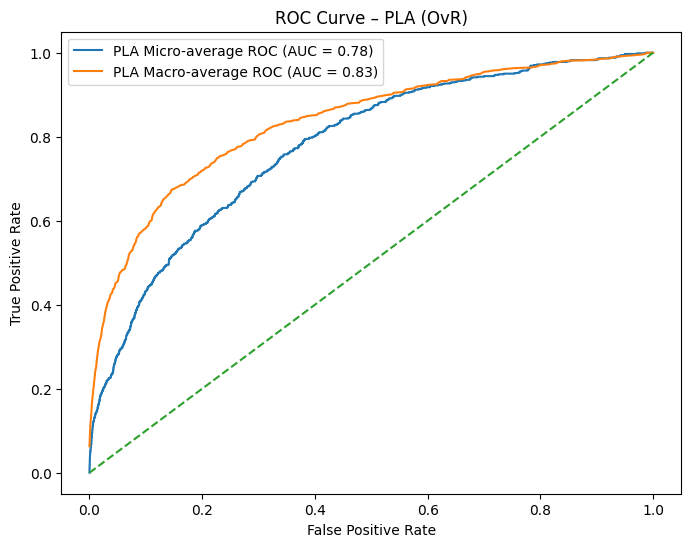

In [24]:
plt.figure(figsize=(8,6))

plt.plot(fpr_micro, tpr_micro,
         label=f'PLA Micro-average ROC (AUC = {roc_auc_micro:.2f})')

plt.plot(all_fpr, mean_tpr,
         label=f'PLA Macro-average ROC (AUC = {roc_auc_macro:.2f})')

plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve – PLA (OvR)')
plt.legend()
plt.show()

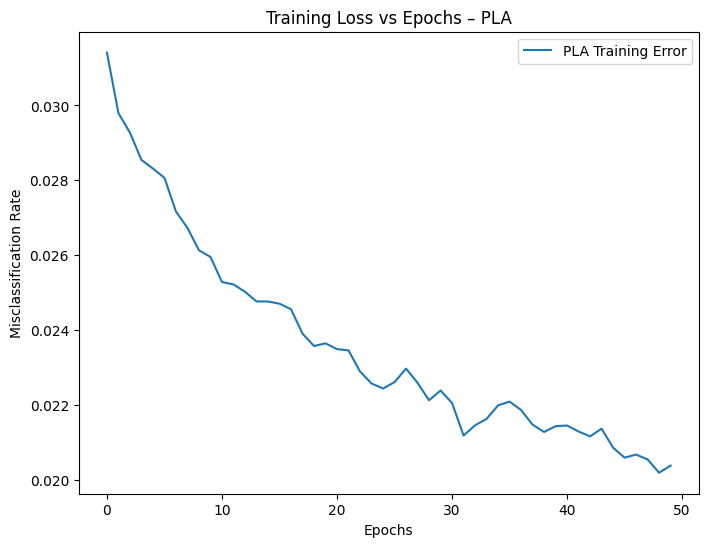

In [25]:
# Average loss across all OvR classifiers
pla_loss = np.mean(
    [clf.loss_history for clf in pla_model.classifiers],
    axis=0
)

plt.figure(figsize=(8,6))
plt.plot(pla_loss, label='PLA Training Error')
plt.xlabel('Epochs')
plt.ylabel('Misclassification Rate')
plt.title('Training Loss vs Epochs – PLA')
plt.legend()
plt.show()

In [26]:
y_pred_pla = pla_model.predict(X_test)


In [27]:
from sklearn.metrics import accuracy_score, classification_report

print("PLA Accuracy:", accuracy_score(y_test, y_pred_pla))
print(classification_report(y_test, y_pred_pla))


PLA Accuracy: 0.15395894428152493
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        11
           1       0.00      0.00      0.00        11
           2       0.00      0.00      0.00        11
           3       0.50      0.09      0.15        11
           4       0.00      0.00      0.00        11
           5       0.00      0.00      0.00        11
           6       0.12      0.45      0.19        11
           7       0.00      0.00      0.00        11
           8       1.00      0.09      0.17        11
           9       0.24      0.36      0.29        11
          10       1.00      0.18      0.31        11
          11       0.00      0.00      0.00        11
          12       0.67      0.55      0.60        11
          13       0.20      0.27      0.23        11
          14       0.25      0.09      0.13        11
          15       0.00      0.00      0.00        11
          16       0.00      0.00      0.00    

C:\Users\KAMALESH\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\KAMALESH\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\KAMALESH\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metri

In [28]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam


In [29]:
mlp_model = Sequential()

# Hidden Layer 1
mlp_model.add(Dense(256, activation='relu', input_shape=(784,)))

# Hidden Layer 2
mlp_model.add(Dense(128, activation='relu'))

# Output Layer
mlp_model.add(Dense(num_classes, activation='softmax'))


C:\Users\KAMALESH\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [30]:
optimizer = Adam(learning_rate=0.001)

mlp_model.compile(
    optimizer=optimizer,
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


In [31]:
history = mlp_model.fit(
    X_train,
    y_train_cat,
    epochs=50,
    batch_size=64,
    validation_split=0.1,
    verbose=1
)


Epoch 1/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.0147 - loss: 4.1851 - val_accuracy: 0.0037 - val_loss: 4.1912
Epoch 2/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.0187 - loss: 4.1295 - val_accuracy: 0.0073 - val_loss: 4.1219
Epoch 3/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.0143 - loss: 4.1142 - val_accuracy: 0.0147 - val_loss: 4.1214
Epoch 4/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.0253 - loss: 4.1101 - val_accuracy: 0.0256 - val_loss: 4.1474
Epoch 5/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.0281 - loss: 4.0972 - val_accuracy: 0.0183 - val_loss: 4.1238
Epoch 6/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.0391 - loss: 4.0700 - val_accuracy: 0.0110 - val_loss: 4.0905
Epoch 7/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.0464 - loss: 4.0117 - val_accuracy: 0.0330 - val_loss: 4.0063
Epoch 8/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.0570 - loss: 3.9092 - val_accuracy: 0.0440 - val_los

In [32]:
mlp_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 62)             │         7,998 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 725,564 (2.77 MB)

 Trainable params: 241,854 (944.74 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 483,710 (1.85 MB)

In [33]:
learning_rates = [0.01, 0.001, 0.0005]
batch_sizes = [32, 64]
optimizers = ['sgd', 'adam']
activations = ['relu', 'tanh']


In [34]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import SGD, Adam


def build_mlp(activation, optimizer_name, learning_rate):
    model = Sequential()
    
    model.add(Dense(256, activation=activation, input_shape=(784,)))
    model.add(Dense(128, activation=activation))
    model.add(Dense(num_classes, activation='softmax'))

    if optimizer_name == 'sgd':
        optimizer = SGD(learning_rate=learning_rate)
    else:
        optimizer = Adam(learning_rate=learning_rate)

    model.compile(
        optimizer=optimizer,
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model


In [35]:
results = []

for activation in activations:
    for opt in optimizers:
        for lr in learning_rates:
            for batch in batch_sizes:
                print(f"Training: Act={activation}, Opt={opt}, LR={lr}, Batch={batch}")

                model = build_mlp(activation, opt, lr)

                model.fit(
                    X_train,
                    y_train_cat,
                    epochs=30,
                    batch_size=batch,
                    validation_split=0.1,
                    verbose=0
                )

                loss, acc = model.evaluate(X_test, y_test_cat, verbose=0)
                results.append([activation, opt, lr, batch, acc])


Training: Act=relu, Opt=sgd, LR=0.01, Batch=32
Training: Act=relu, Opt=sgd, LR=0.01, Batch=64
Training: Act=relu, Opt=sgd, LR=0.001, Batch=32
Training: Act=relu, Opt=sgd, LR=0.001, Batch=64
Training: Act=relu, Opt=sgd, LR=0.0005, Batch=32
Training: Act=relu, Opt=sgd, LR=0.0005, Batch=64
Training: Act=relu, Opt=adam, LR=0.01, Batch=32
Training: Act=relu, Opt=adam, LR=0.01, Batch=64
Training: Act=relu, Opt=adam, LR=0.001, Batch=32
Training: Act=relu, Opt=adam, LR=0.001, Batch=64
Training: Act=relu, Opt=adam, LR=0.0005, Batch=32
Training: Act=relu, Opt=adam, LR=0.0005, Batch=64
Training: Act=tanh, Opt=sgd, LR=0.01, Batch=32
Training: Act=tanh, Opt=sgd, LR=0.01, Batch=64
Training: Act=tanh, Opt=sgd, LR=0.001, Batch=32
Training: Act=tanh, Opt=sgd, LR=0.001, Batch=64
Training: Act=tanh, Opt=sgd, LR=0.0005, Batch=32
Training: Act=tanh, Opt=sgd, LR=0.0005, Batch=64
Training: Act=tanh, Opt=adam, LR=0.01, Batch=32
Training: Act=tanh, Opt=adam, LR=0.01, Batch=64
Training: Act=tanh, Opt=adam, LR=0

In [36]:
import pandas as pd

results_df = pd.DataFrame(
    results,
    columns=['Activation', 'Optimizer', 'Learning Rate', 'Batch Size', 'Accuracy']
)

print(results_df.sort_values(by='Accuracy', ascending=False))


   Activation Optimizer  Learning Rate  Batch Size  Accuracy
23       tanh      adam         0.0005          64  0.324047
22       tanh      adam         0.0005          32  0.321114
9        relu      adam         0.0010          64  0.296188
21       tanh      adam         0.0010          64  0.285924
10       relu      adam         0.0005          32  0.274194
11       relu      adam         0.0005          64  0.271261
12       tanh       sgd         0.0100          32  0.259531
8        relu      adam         0.0010          32  0.246334
0        relu       sgd         0.0100          32  0.224340
20       tanh      adam         0.0010          32  0.145161
13       tanh       sgd         0.0100          64  0.126100
1        relu       sgd         0.0100          64  0.115836
14       tanh       sgd         0.0010          32  0.045455
2        relu       sgd         0.0010          32  0.043988
3        relu       sgd         0.0010          64  0.035191
4        relu       sgd 

In [37]:
best_params = results_df.loc[results_df['Accuracy'].idxmax()]
print("Best Hyperparameters:")
print(best_params)


Best Hyperparameters:
Activation           tanh
Optimizer            adam
Learning Rate      0.0005
Batch Size             64
Accuracy         0.324047
Name: 23, dtype: object


In [38]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)
import matplotlib.pyplot as plt
import seaborn as sns


In [39]:
pla_accuracy = accuracy_score(y_test, y_pred_pla)
pla_precision = precision_score(y_test, y_pred_pla, average='macro', zero_division=0)
pla_recall = recall_score(y_test, y_pred_pla, average='macro', zero_division=0)
pla_f1 = f1_score(y_test, y_pred_pla, average='macro', zero_division=0)

print("PLA Performance:")
print("Accuracy :", pla_accuracy)
print("Precision:", pla_precision)
print("Recall   :", pla_recall)
print("F1-score :", pla_f1)


PLA Performance:
Accuracy : 0.15395894428152493
Precision: 0.21879175582893162
Recall   : 0.15395894428152496
F1-score : 0.11751540417519936


In [40]:
# Predict probabilities
y_pred_prob = mlp_model.predict(X_test)

# Convert probabilities to class labels
y_pred_mlp = np.argmax(y_pred_prob, axis=1)


22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step


In [41]:
mlp_accuracy = accuracy_score(y_test, y_pred_mlp)
mlp_precision = precision_score(y_test, y_pred_mlp, average='macro')
mlp_recall = recall_score(y_test, y_pred_mlp, average='macro')
mlp_f1 = f1_score(y_test, y_pred_mlp, average='macro')

print("\nMLP Performance:")
print("Accuracy :", mlp_accuracy)
print("Precision:", mlp_precision)
print("Recall   :", mlp_recall)
print("F1-score :", mlp_f1)



MLP Performance:
Accuracy : 0.36363636363636365
Precision: 0.3971453062579164
Recall   : 0.3636363636363636
F1-score : 0.34867447573491456


In [42]:
comparison_df = pd.DataFrame({
    "Model": ["PLA (OvR)", "MLP (Tuned)"],
    "Accuracy": [pla_accuracy, mlp_accuracy],
    "Precision": [pla_precision, mlp_precision],
    "Recall": [pla_recall, mlp_recall],
    "F1-score": [pla_f1, mlp_f1]
})

print(comparison_df)


         Model  Accuracy  Precision    Recall  F1-score
0    PLA (OvR)  0.153959   0.218792  0.153959  0.117515
1  MLP (Tuned)  0.363636   0.397145  0.363636  0.348674


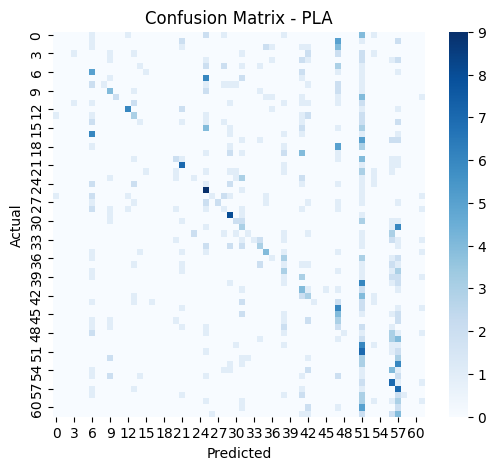

In [43]:
cm_pla = confusion_matrix(y_test, y_pred_pla)

plt.figure(figsize=(6,5))
sns.heatmap(cm_pla, cmap="Blues", cbar=True)
plt.title("Confusion Matrix - PLA")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


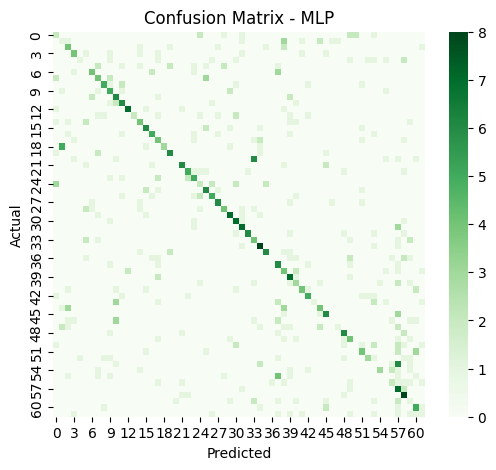

In [44]:
cm_mlp = confusion_matrix(y_test, y_pred_mlp)

plt.figure(figsize=(6,5))
sns.heatmap(cm_mlp, cmap="Greens", cbar=True)
plt.title("Confusion Matrix - MLP")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


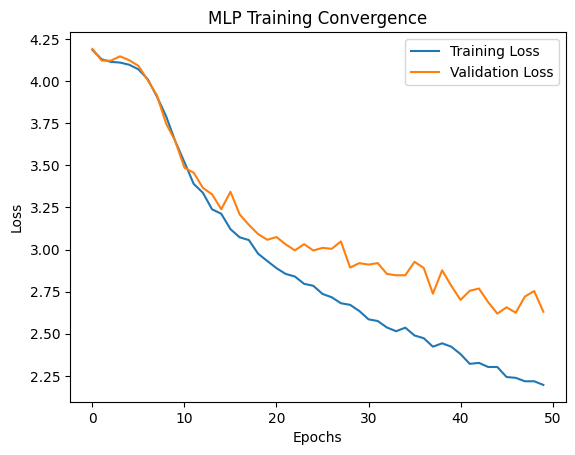

In [45]:
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("MLP Training Convergence")
plt.legend()
plt.show()


In [46]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import numpy as np


In [47]:
# Get probability scores from MLP
y_score = mlp_model.predict(X_test)


22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


In [48]:
# Binarize labels for ROC computation
y_test_bin = label_binarize(y_test, classes=range(num_classes))


In [49]:
fpr_micro, tpr_micro, _ = roc_curve(
    y_test_bin.ravel(),
    y_score.ravel()
)

roc_auc_micro = auc(fpr_micro, tpr_micro)


In [50]:
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(num_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Aggregate all false positive rates
all_fpr = np.unique(np.concatenate([fpr[i] for i in range(num_classes)]))

mean_tpr = np.zeros_like(all_fpr)
for i in range(num_classes):
    mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])

mean_tpr /= num_classes

fpr_macro = all_fpr
tpr_macro = mean_tpr
roc_auc_macro = auc(fpr_macro, tpr_macro)


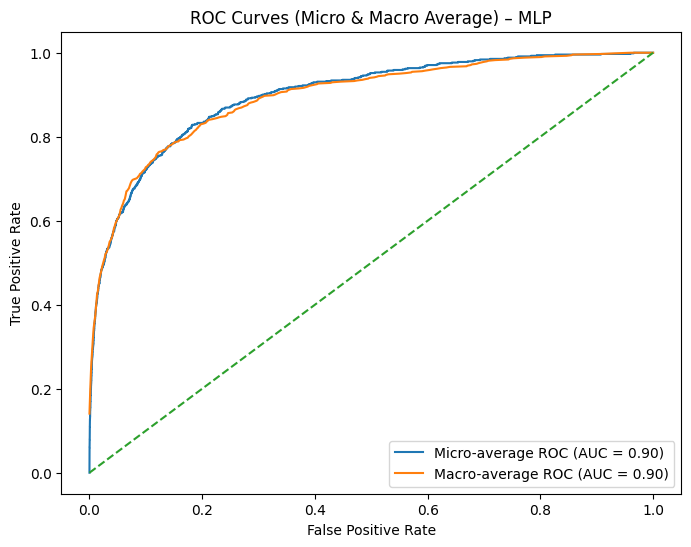

In [51]:
plt.figure(figsize=(8,6))

plt.plot(fpr_micro, tpr_micro,
         label=f'Micro-average ROC (AUC = {roc_auc_micro:.2f})')

plt.plot(fpr_macro, tpr_macro,
         label=f'Macro-average ROC (AUC = {roc_auc_macro:.2f})')

plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves (Micro & Macro Average) – MLP')
plt.legend()
plt.show()


In [52]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import SGD, Adam
from sklearn.metrics import accuracy_score
import numpy as np

In [53]:
def build_mlp(hidden_layers, activation, optimizer_name, learning_rate, input_dim, num_classes):
    model = Sequential()

    # First hidden layer
    model.add(Dense(hidden_layers[0], activation=activation, input_shape=(input_dim,)))

    # Additional hidden layers
    for units in hidden_layers[1:]:
        model.add(Dense(units, activation=activation))

    # Output layer
    model.add(Dense(num_classes, activation='softmax'))

    # Optimizer selection
    if optimizer_name == 'SGD':
        optimizer = SGD(learning_rate=learning_rate)
    else:
        optimizer = Adam(learning_rate=learning_rate)

    model.compile(
        optimizer=optimizer,
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

In [54]:
configs = [
    ([128], 'relu', 'SGD', 0.01, 32),
    ([256, 128], 'relu', 'Adam', 0.001, 64),
    ([512, 256, 128], 'tanh', 'Adam', 0.0005, 64)
]

results = []

for hidden_layers, activation, optimizer, lr, batch_size in configs:
    print(f"\nTraining MLP with {hidden_layers}, {activation}, {optimizer}, LR={lr}, Batch={batch_size}")

    model = build_mlp(
        hidden_layers=hidden_layers,
        activation=activation,
        optimizer_name=optimizer,
        learning_rate=lr,
        input_dim=784,
        num_classes=num_classes
    )

    model.fit(
        X_train,
        y_train_cat,
        epochs=15,
        batch_size=batch_size,
        validation_split=0.1,
        verbose=0
    )

    y_pred = np.argmax(model.predict(X_test), axis=1)
    acc = accuracy_score(y_test, y_pred)

    results.append([hidden_layers, activation, optimizer, lr, batch_size, acc])


Training MLP with [128], relu, SGD, LR=0.01, Batch=32


C:\Users\KAMALESH\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step

Training MLP with [256, 128], relu, Adam, LR=0.001, Batch=64


C:\Users\KAMALESH\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step

Training MLP with [512, 256, 128], tanh, Adam, LR=0.0005, Batch=64


C:\Users\KAMALESH\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step


In [55]:
for r in results:
    print(f"Hidden Layers: {r[0]}, Activation: {r[1]}, Optimizer: {r[2]}, "
          f"LR: {r[3]}, Batch: {r[4]}, Accuracy: {r[5]*100:.2f}%")

Hidden Layers: [128], Activation: relu, Optimizer: SGD, LR: 0.01, Batch: 32, Accuracy: 6.60%
Hidden Layers: [256, 128], Activation: relu, Optimizer: Adam, LR: 0.001, Batch: 64, Accuracy: 1.61%
Hidden Layers: [512, 256, 128], Activation: tanh, Optimizer: Adam, LR: 0.0005, Batch: 64, Accuracy: 27.13%


In [56]:
class Perceptron:
    def __init__(self, lr=0.01, epochs=20):
        self.lr = lr
        self.epochs = epochs
        self.weights = None
        self.bias = None
        self.loss_history = []

    def fit(self, X, y):
        self.weights = np.zeros(X.shape[1])
        self.bias = 0

        for _ in range(self.epochs):
            errors = 0
            for xi, yi in zip(X, y):
                linear = np.dot(xi, self.weights) + self.bias
                y_pred = 1 if linear >= 0 else 0
                update = self.lr * (yi - y_pred)
                self.weights += update * xi
                self.bias += update
                if yi != y_pred:
                    errors += 1

            loss = errors / len(y)   # misclassification rate
            self.loss_history.append(loss)

In [57]:
pla_epochs = len(pla_model.classifiers[0].loss_history)
pla_final_loss = np.mean(
    [clf.loss_history[-1] for clf in pla_model.classifiers]
)

print("PLA Epochs:", pla_epochs)
print("PLA Final Training Loss:", pla_final_loss)
print("PLA Convergence: Non-convergent")

PLA Epochs: 50
PLA Final Training Loss: 0.020385961593037554
PLA Convergence: Non-convergent


In [58]:
mlp_epochs = len(history.history['loss'])
mlp_final_loss = history.history['loss'][-1]

print("MLP Epochs:", mlp_epochs)
print("MLP Final Training Loss:", mlp_final_loss)
print("MLP Convergence: Stable convergence")

MLP Epochs: 50
MLP Final Training Loss: 2.196075439453125
MLP Convergence: Stable convergence
